In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Temperature Analysis

Generate hourly temperature data for one week using NumPy.

In [2]:
temp = {}
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
for day in days:
    one = np.random.randint(30,35,8)
    two = np.random.randint(35,40,8)
    three = np.random.randint(30,35,8)

    temp[day] = np.concatenate([np.random.randint(30,33,6), np.random.randint(33,35,3), np.random.randint(35,37,3),
                                np.random.randint(37,40,3), np.random.randint(36,39,3), np.random.randint(33,35,3),
                                np.random.randint(30,33,3)])

In [3]:
temp

{'Mon': array([31, 32, 30, 30, 32, 31, 33, 34, 34, 35, 36, 36, 38, 38, 37, 36, 36,
        38, 34, 33, 34, 32, 30, 31]),
 'Tue': array([31, 31, 30, 32, 30, 32, 34, 34, 33, 35, 35, 36, 37, 39, 37, 38, 37,
        37, 34, 34, 33, 32, 31, 31]),
 'Wed': array([32, 30, 30, 32, 30, 31, 33, 34, 34, 36, 36, 36, 39, 38, 38, 38, 36,
        36, 33, 34, 33, 31, 31, 30]),
 'Thu': array([31, 31, 32, 31, 31, 30, 34, 33, 33, 35, 35, 36, 38, 39, 37, 37, 38,
        37, 34, 33, 34, 32, 30, 32]),
 'Fri': array([30, 31, 31, 31, 32, 30, 33, 33, 33, 35, 35, 35, 39, 39, 37, 36, 38,
        36, 34, 33, 33, 32, 32, 32]),
 'Sat': array([30, 31, 31, 32, 31, 31, 34, 34, 33, 35, 35, 35, 38, 39, 39, 38, 37,
        36, 34, 33, 34, 31, 30, 32]),
 'Sun': array([30, 31, 31, 30, 31, 32, 33, 33, 33, 35, 36, 36, 38, 37, 37, 37, 38,
        37, 33, 33, 34, 31, 31, 31])}

Store it in a Pandas DataFrame with datetime index.

In [4]:
temp_df = pd.DataFrame(temp, index=[f"{h}:00" for h in range(24)])
temp_df.head()

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
0:00,31,31,32,31,30,30,30
1:00,32,31,30,31,31,31,31
2:00,30,30,30,32,31,31,31
3:00,30,32,32,31,31,32,30
4:00,32,30,30,31,32,31,31


In [5]:
temp_df['Avg_temp'] = temp_df.mean(axis=1)

In [6]:
temp_df.head()

,Mon,Tue,Wed,Thu,Fri,Sat,Sun,Avg_temp
0:00,31,31,32,31,30,30,30,30.714286
1:00,32,31,30,31,31,31,31,31.000000
2:00,30,30,30,32,31,31,31,30.714286
3:00,30,32,32,31,31,32,30,31.142857
4:00,32,30,30,31,32,31,31,31.000000


Plot the temperature trend over the week using a line chart.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


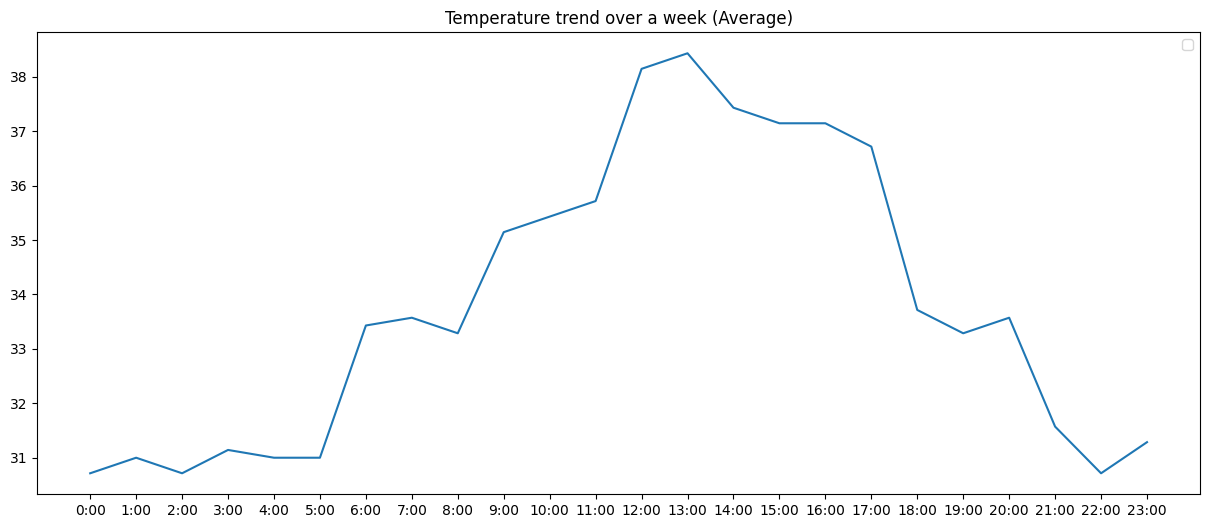

In [7]:
plt.figure(figsize=(15,6))
plt.plot(temp_df['Avg_temp'])
plt.legend()
plt.title("Temperature trend over a week (Average)")
plt.show()

### Random Sales Dataset

Simulate sales data for 5 products over 30 days:
 - Columns: "date", "product", "units_sold", "unit_price".


In [8]:
date =  np.datetime64('2025-01-01')
dates = [date + i for i in range(30)]

In [9]:
sales_data = {
    "date" : dates,
    "product" : np.arange(1,31),
    "units_sold" : np.random.randint(0,20,30),
    "unit_price" : np.random.randint(30,100,30)
}

In [10]:
sales_df = pd.DataFrame(sales_data, index=[n for n in range(1,31)])

Compute total revenue per product.

In [11]:
sales_df['revenue'] = sales_df['unit_price']*sales_df['units_sold']
sales_df.head()

,date,product,units_sold,unit_price,revenue
1,2025-01-01,1,1,53,53
2,2025-01-02,2,16,74,1184
3,2025-01-03,3,1,70,70
4,2025-01-04,4,18,45,810
5,2025-01-05,5,15,78,1170


Plot a bar chart of revenue by product.

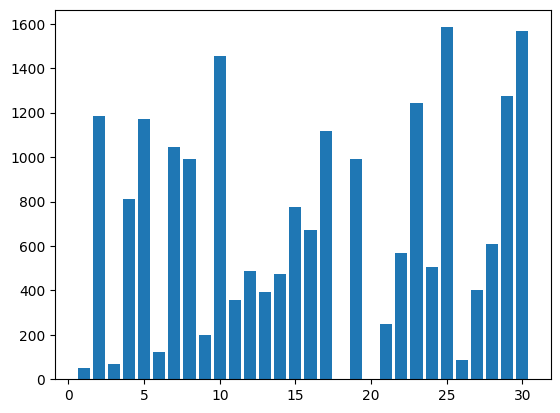

In [12]:
plt.bar(sales_df['product'], sales_df['revenue'])
plt.show()

### Missing Data Handling

Create a DataFrame with some missing values:

In [13]:
numerical_data = np.random.randint(1,10,10).astype('float')
numerical_data[[2,5,7]] = np.nan

In [14]:
data = {
    "numerical" : numerical_data,
    "categorical": np.random.choice([np.nan, "a", "b", "c", "d"], size=10),
    }

In [15]:
data_df = pd.DataFrame(data)
data_df

,numerical,categorical
0,4.0,b
1,5.0,c
2,NaN,a
3,7.0,a
4,2.0,d
5,NaN,b
6,8.0,c
7,NaN,c
8,3.0,d
9,3.0,nan


In [16]:
data_bofore = data_df.copy()

- Fill missing numeric values with the mean.
- Fill missing categorical values with mode.


In [17]:
data_df['categorical'] = data_df['categorical'].replace('nan', np.nan)
data_df['numerical'] = data_df['numerical'].fillna(data_df['numerical'].mean())
data_df['categorical'] = data_df['categorical'].fillna(data_df['categorical'].mode()[0])
data_df


,numerical,categorical
0,4.000000,b
1,5.000000,c
2,4.571429,a
3,7.000000,a
4,2.000000,d
5,4.571429,b
6,8.000000,c
7,4.571429,c
8,3.000000,d
9,3.000000,c


Plot before vs after comparison using boxplots.


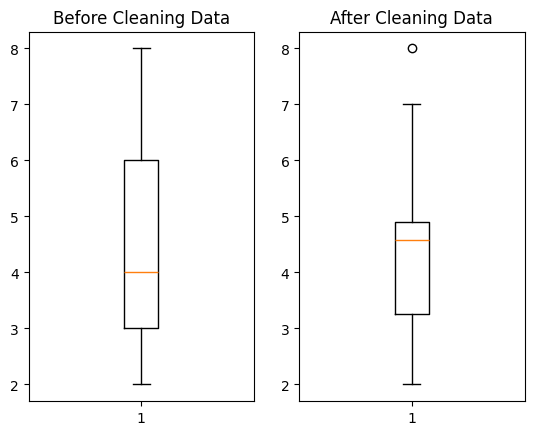

In [18]:
plt.subplot(1,2,1)
plt.boxplot(data_bofore['numerical'].dropna())
plt.title("Before Cleaning Data")

plt.subplot(1,2,2)
plt.boxplot(data_df['numerical'])
plt.title("After Cleaning Data")
plt.show()

### Customer Segregation

Simulate a customer dataset with features like "age", "income", "spending_score".

In [19]:
customer_data = {
    "age" : np.random.randint(18,50,100),
    "income" : np.random.randint(3000000, 12000000,100),
    "spending_score" : np.random.randint(1,101,100)
}
customer_df = pd.DataFrame(customer_data)
customer_df.head()

,age,income,spending_score
0,49,9490257,100
1,23,5086719,75
2,35,5973160,16
3,21,9177921,93
4,48,6467964,9


Use quantile-based binning to categorize customers into Low, Medium, High spenders.

In [20]:
conditions = [customer_df['spending_score']  <= 30, 
              (customer_df['spending_score'] > 30) & (customer_df['spending_score'] < 70),
              customer_df['spending_score'] >= 70]
category = ['Low','Medium', 'High']

customer_df['type_of_spendor'] = np.select(conditions,category)
customer_df

,age,income,spending_score,type_of_spendor
0,49,9490257,100,High
1,23,5086719,75,High
2,35,5973160,16,Low
3,21,9177921,93,High
4,48,6467964,9,Low
...,...,...,...,...
95,44,9793595,98,High
96,31,6782723,83,High
97,46,10538809,16,Low
98,19,5240312,95,High


Visualize age vs income, colored by spending category (scatter plot)

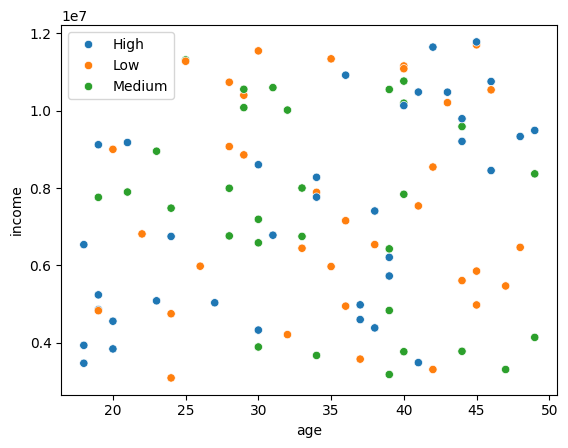

In [21]:
sns.scatterplot(x='age', y ='income',data=customer_df, hue='type_of_spendor')
plt.legend(loc=0)
plt.show()

### Time Series Resampling

Generate minute-level stock price data for a day.

In [22]:
prices =  np.random.rand(60*24)
minutes = np.arange(60*24)

time = pd.to_timedelta(minutes, unit='m').astype(str)
time = [time.split()[-1] for time in time]

stock_minute ={"prices": prices,
               "time" : time
               }
stock_minute_df = pd.DataFrame(stock_minute, index=time)
stock_minute_df.head()

,prices,time
00:00:00,0.829652,00:00:00
00:01:00,0.550613,00:01:00
00:02:00,0.922613,00:02:00
00:03:00,0.019320,00:03:00
00:04:00,0.398215,00:04:00


Resample it to hourly average prices using Pandas.

In [23]:
stock_minute_df['hour'] = stock_minute_df['time'].str.slice(0,2)
stock_hour_df = stock_minute_df.groupby("hour",as_index=False)['prices'].mean()
stock_hour_df.head()

,hour,prices
0,00,0.501875
1,01,0.458970
2,02,0.396534
3,03,0.513937
4,04,0.484049


Plot both the original and resampled series.

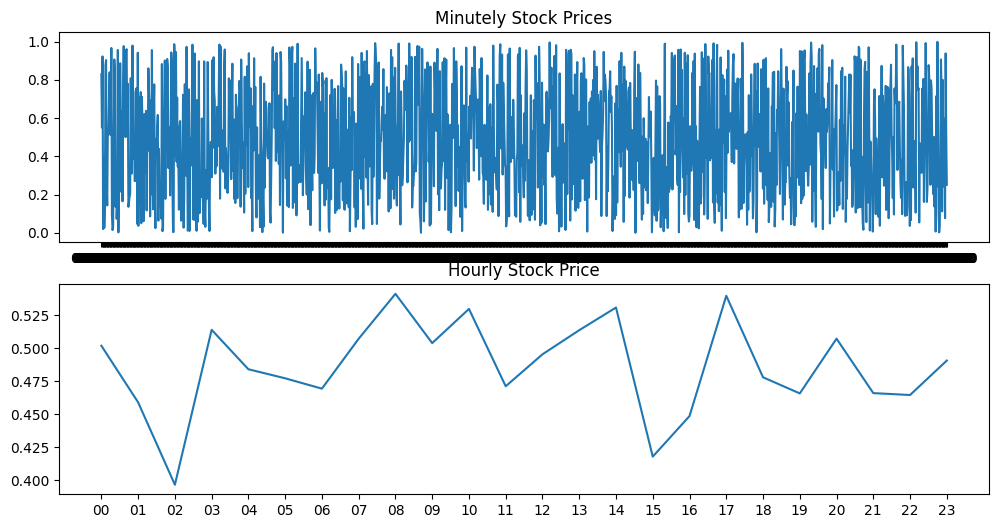

In [24]:
fig,axs = plt.subplots(nrows = 2, ncols = 1, figsize=(12,6))

axs[0].plot(stock_minute_df['time'],stock_minute_df['prices'])
axs[0].set_title("Minutely Stock Prices")

axs[1].plot(stock_hour_df['hour'],stock_hour_df['prices'])
axs[1].set_title("Hourly Stock Price")
plt.show()


### Outlier Detection

Create a dataset of test scores with intentional outliers.

In [25]:
scores = np.random.randint(60,90,100)
scores[[3,67,90]] = 20
scores[[7,23]] = 10
scores[[10,48,66]] = 110

scores

array([ 72,  81,  67,  20,  76,  82,  60,  10,  85,  76, 110,  74,  74,
        71,  87,  88,  60,  84,  77,  87,  73,  69,  84,  10,  72,  88,
        72,  66,  89,  83,  78,  67,  60,  82,  89,  74,  62,  76,  87,
        85,  61,  89,  77,  66,  82,  77,  75,  60, 110,  62,  84,  73,
        62,  78,  85,  85,  68,  74,  63,  68,  63,  87,  79,  63,  62,
        75, 110,  20,  87,  66,  61,  84,  84,  67,  85,  67,  78,  61,
        89,  81,  77,  60,  65,  76,  71,  84,  84,  67,  78,  73,  20,
        62,  74,  70,  65,  66,  81,  87,  88,  70])

In [26]:
scores_df = pd.DataFrame(scores)
scores_df_with_outliers = scores_df.copy()

Detect outliers using IQR method.

In [27]:
median = scores_df.quantile(0.5)
quantiles = scores_df.quantile([0.25,0.75])
q1 = quantiles[0][0.25]
q3 = quantiles[0][0.75]
iqr = q3 - q1
lower_fence = q1 - 1.5*iqr
upper_fence = q3 + 1.5*iqr


Remove them and plot before/after distributions side-by-side.

In [28]:
scores_df_without_outliers = scores_df[(scores_df[0]>lower_fence) & (scores_df[0]<upper_fence)]

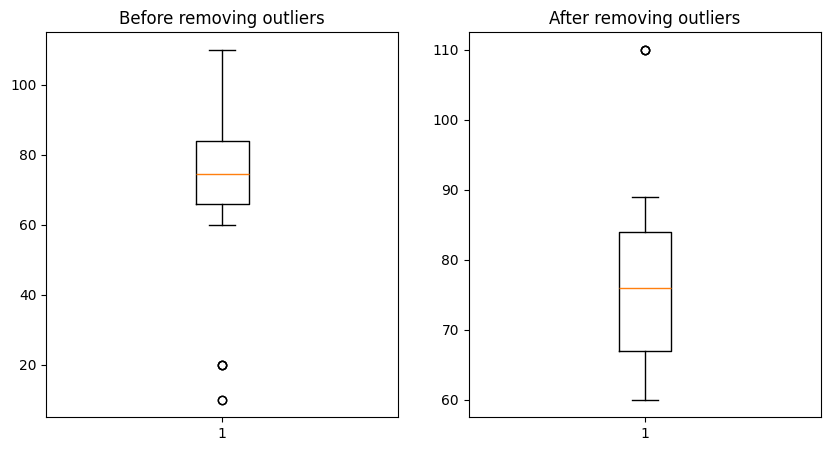

In [29]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.boxplot(scores_df_with_outliers)
plt.title("Before removing outliers")

plt.subplot(1,2,2)
plt.boxplot(scores_df_without_outliers)
plt.title("After removing outliers")
plt.show()

### Correlation Matrix

Simulate a dataset with multiple continuous variables.

In [30]:
customer_df

,age,income,spending_score,type_of_spendor
0,49,9490257,100,High
1,23,5086719,75,High
2,35,5973160,16,Low
3,21,9177921,93,High
4,48,6467964,9,Low
...,...,...,...,...
95,44,9793595,98,High
96,31,6782723,83,High
97,46,10538809,16,Low
98,19,5240312,95,High


In [31]:
customer_df.sort_values('age',inplace=True)
customer_df.drop('type_of_spendor',axis=1, inplace=True)

Compute the correlation matrix.

In [32]:
customer_df_corr = customer_df.corr()
customer_df_corr

,age,income,spending_score
age,1.000000,0.156247,-0.081823
income,0.156247,1.000000,0.015790
spending_score,-0.081823,0.015790,1.000000


Plot a heatmap of correlations using Seaborn.

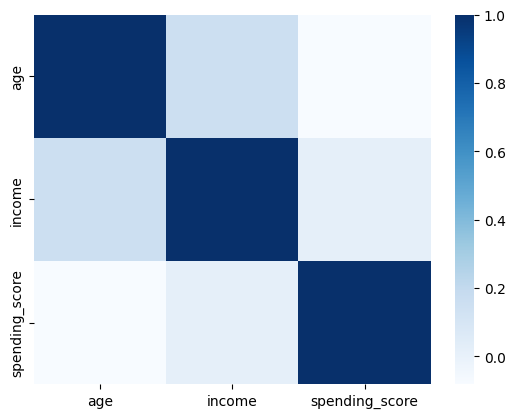

In [33]:
sns.heatmap(customer_df_corr, cmap='Blues')
plt.show()

### Multi-Index DataFrame

Simulate sales data with multi-level index (store, date).


In [34]:
stores = [1,2,3,4,5]
start_date =  np.datetime64('2025-01-01')
dates = [start_date + i for i in range(30)]

multi_index = pd.MultiIndex.from_product([stores,dates], names=['store','date'])
product = np.random.choice(['a','b','c','d','e'], size=len(multi_index))
unit_price_map = {'a': 10, 'b': 15, 'c': 12, 'd': 8, 'e': 20}

store_data = {
    "products" : product,
    "units_sold" : np.random.randint(1,10,len(multi_index))
}

store_data_df = pd.DataFrame(store_data, index=multi_index)
store_data_df['unit_price'] = store_data_df['products'].map(unit_price_map)
store_data_df['revenue'] = store_data_df['unit_price']*store_data_df['units_sold']


In [35]:
store_data_df

products  units_sold  unit_price  revenue
store date                                                
1     2025-01-01        b           2          15       30
      2025-01-02        c           8          12       96
      2025-01-03        c           9          12      108
      2025-01-04        a           6          10       60
      2025-01-05        b           3          15       45
...                   ...         ...         ...      ...
5     2025-01-26        a           4          10       40
      2025-01-27        c           4          12       48
      2025-01-28        a           5          10       50
      2025-01-29        a           2          10       20
      2025-01-30        a           4          10       40

[150 rows x 4 columns]

Compute total and average sales per store.

In [36]:
store_total = store_data_df.groupby('store').sum()
store_total

,products,units_sold,unit_price,revenue
store,,,,
1,bccabecbbabebeabbcbceadedbebbd,158,424,2248
2,ebaccaaeebccdedbddacbdbbcaaebc,154,389,2000
3,abcbaecabcbdabaeeaeaabdaadcaea,140,382,1738
4,bedebdacabcbcabebbbdabeecadcba,166,402,2131
5,bbddcbeaceaecdaaacacadadeacaaa,126,357,1523


In [37]:
store_mean = store_data_df.groupby('store').mean(numeric_only=True)
store_mean

,units_sold,unit_price,revenue
store,,,
1,5.266667,14.133333,74.933333
2,5.133333,12.966667,66.666667
3,4.666667,12.733333,57.933333
4,5.533333,13.400000,71.033333
5,4.200000,11.900000,50.766667


Visualize store-wise sales using stacked bar chart.

In [38]:
revenue_by_store = store_data_df.groupby(['store','products'])['revenue'].sum().unstack(fill_value=0)
revenue_by_store

products,a,b,c,d,e
store,,,,,
1,180,840,336,152,740
2,230,570,504,216,480
3,640,330,144,144,480
4,390,705,396,200,440
5,620,195,324,64,320


Text(0.5, 1.0, 'Store Revenue Data by product')

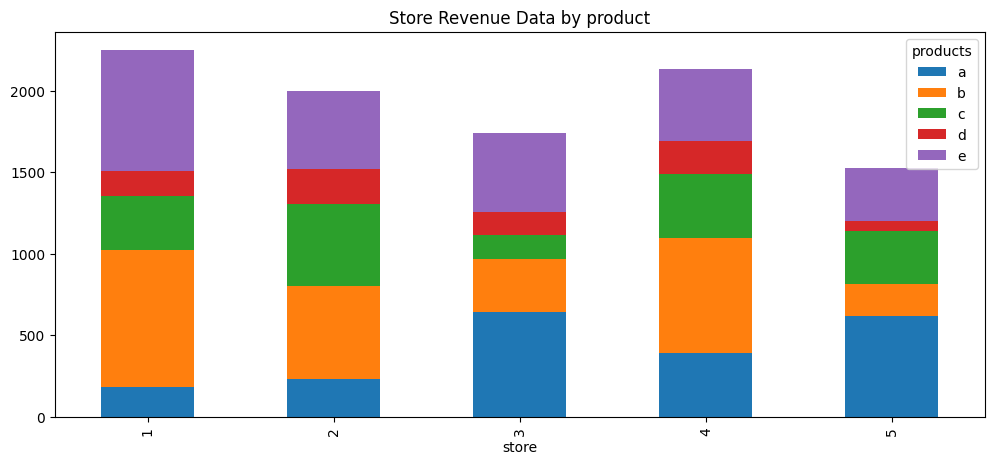

In [39]:
revenue_by_store.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Store Revenue Data by product")

### Crosstab Analysis

Create a dataset of customer purchases:
- Columns: "gender", "age_group", "product_category", "purchase_amount".


In [40]:
customer_purchase = {
    "gender" : np.random.choice(["Male","Female"], size=100),
    "age_group" : np.random.choice(['<18','18-25','25-35','35-45','>45'],size=100),
    "product_category" : np.random.choice(["Electronics", "Food", "Medical", "Clothes", "Shoes", "Others"], size=100),
    "purchase_amount" : np.random.randint(100,500,100)
}
index = np.arange(1, 101)
customer_purchase_df = pd.DataFrame(customer_purchase,index=index)
customer_purchase_df

,gender,age_group,product_category,purchase_amount
1,Female,25-35,Electronics,234
2,Female,35-45,Medical,305
3,Female,35-45,Electronics,396
4,Female,18-25,Medical,419
5,Male,25-35,Electronics,388
...,...,...,...,...
96,Male,<18,Electronics,340
97,Female,>45,Medical,188
98,Male,35-45,Shoes,358
99,Male,25-35,Shoes,423


Generate a crosstab of gender vs product category.

In [41]:
crosstab = pd.crosstab(customer_purchase_df['gender'], customer_purchase_df['product_category'])
crosstab

product_category,Clothes,Electronics,Food,Medical,Others,Shoes
gender,,,,,,
Female,2,7,2,9,9,8
Male,10,13,11,4,11,14


Visualize with a grouped bar chart.

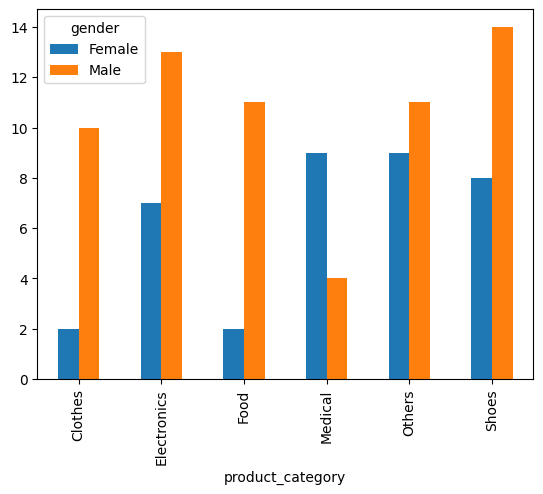

In [42]:
crosstab.T.plot(kind='bar')
plt.show()

### Rolling Averages

Simulate website traffic data (visits per day for 100 days).

In [43]:
dates = pd.date_range(start='2024-01-01', periods=100)
visits = np.random.poisson(lam=300, size=100) + np.random.normal(0, 20, size=100).astype(int)

Compute 7-day and 30-day rolling averages.

In [44]:
df = pd.DataFrame({'Date': dates, 'Visits': visits})
df.set_index('Date', inplace=True)

df['7-day Avg'] = df['Visits'].rolling(window=7).mean()
df['30-day Avg'] = df['Visits'].rolling(window=30).mean()

Plot all three (original, 7-day, 30-day) on the same chart.

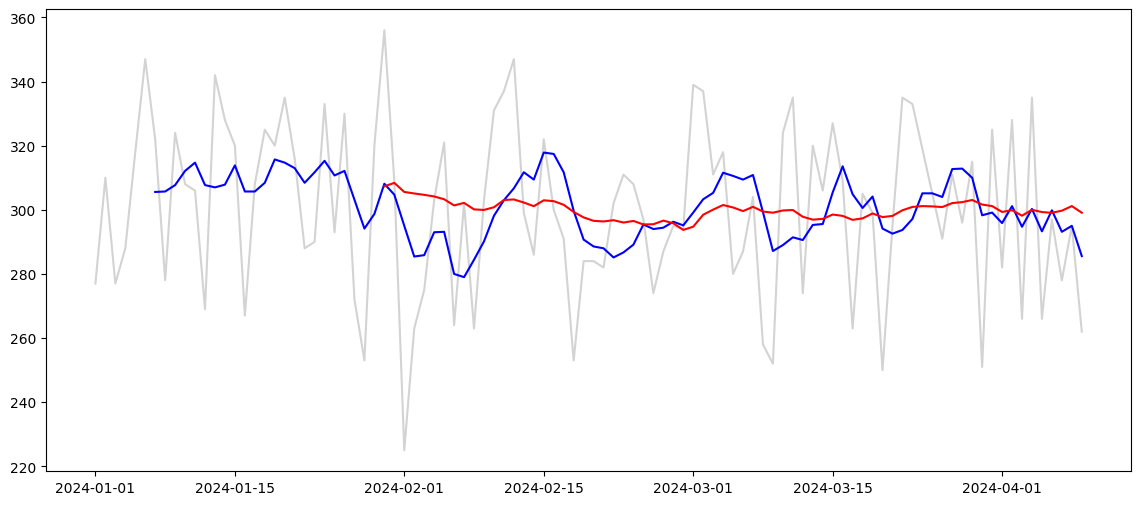

In [45]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Visits'], color='lightgray')
plt.plot(df.index, df['7-day Avg'], color='blue')
plt.plot(df.index, df['30-day Avg'], color='red')

plt.show()
